# <center> Линейная алгебра в контексте линейных методов. Практика.

## <center> Прогнозирование выработки газа на скважинах.

## Постановка задачи

У Василия, основателя компании «Газ-Таз-Ваз-Нефть», дела идут в гору: у него уже функционирует 200 скважин для добычи газа. В этом году он открывает 30 новых скважин. Однако в целях оптимизации расходов и повышения дохода Василию необходимо оценить, сколько денег будет приносить ему каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа. Для этого Василий решил нанять вас как специалиста в области Data Science.

Василий представляет вам набор данных о добыче газа на своих скважинах. Файл с данными вы можете скачать на платформе.

**Признаки в данных:**

* Well — идентификатор скважины;
* Por — пористость скважины (%);
* Perm — проницаемость скважины;
* AI — акустический импеданс ($кг/м^2 * 10^6$);
* Brittle — коэффициент хрупкости скважины (%);
* TOC — общий органический углерод (%);
* VR — коэффициент отражения витринита (%);
* Prod — добыча газа в сутки (млн. кубических футов).

**Ваша задача** — построить регрессионную модель, которая прогнозирует выработку газа на скважине (целевой признак — Prod) на основе остальных характеристик скважины, и проинтерпретировать результаты вашей модели.

Разделим задачу на две части:
* В первой мы построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.
* Во второй мы займёмся построением модели полиномиальной регрессии с регуляризацией и посмотрим на итоговые результаты моделирования.


Импортируем необходимые библиотеки:

In [193]:
# Импорт библиотек
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
import seaborn as sns # библиотека для визуализации статистических данных
import matplotlib.pyplot as plt # для построения графиков
import scipy.stats as stats
from sklearn import metrics
from sklearn import linear_model

%matplotlib inline

Прочитаем исходные данные:

In [194]:
data = pd.read_csv('data/unconv.csv')
data.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


## Практика: линейная регрессия по методу наименьших квадратов

Для начала построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9.

### Задание 5.0. (не оценивается)

Проведите небольшой разведывательный анализ, чтобы поближе познакомиться с исходными данными. Постройте несколько визуализаций, которые помогут вам понять, как устроены исходные признаки, а также смогут продемонстрировать взаимосвязь факторов. 

Сделайте промежуточные выводы из проведённого разведывательного анализа.

In [195]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Well     200 non-null    int64  
 1   Por      200 non-null    float64
 2   Perm     200 non-null    float64
 3   AI       200 non-null    float64
 4   Brittle  200 non-null    float64
 5   TOC      200 non-null    float64
 6   VR       200 non-null    float64
 7   Prod     200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [196]:
# Проверка на пропуски
print(data.isnull().sum().sort_values(ascending=False))

Well       0
Por        0
Perm       0
AI         0
Brittle    0
TOC        0
VR         0
Prod       0
dtype: int64


In [197]:
# Проверить количество дубликатов
print(f"Всего дубликатов строк: {data.duplicated().sum()}")

Всего дубликатов строк: 0


In [198]:
# создаём список числовых признаков и таргет
target = 'Prod'
features = [col for col in data.columns if col != target]
all_columns = features + [target]

print(features, target)

['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR'] Prod


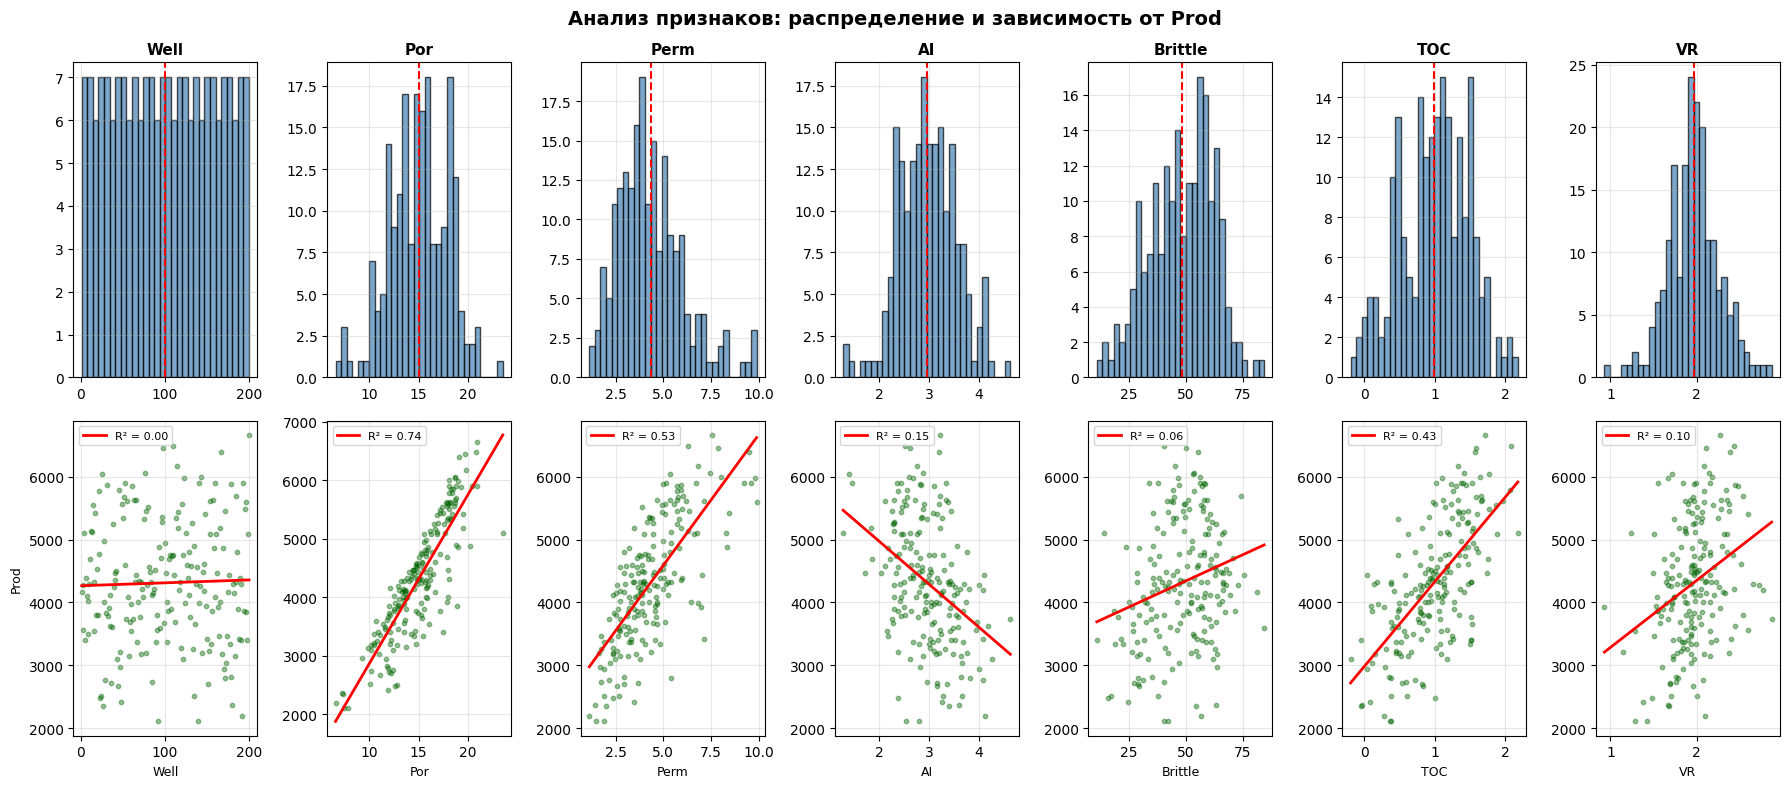

In [199]:
# Построение графика
fig, axes = plt.subplots(2, len(features), figsize=(18, 8))
fig.suptitle('Анализ признаков: распределение и зависимость от Prod', 
             fontsize=14, fontweight='bold')

for i, feature in enumerate(features):
    # Верхний ряд: гистограмма распределения
    axes[0, i].hist(data[feature], bins=30, color='steelblue', 
                    edgecolor='black', alpha=0.7)
    axes[0, i].axvline(data[feature].mean(), color='red', 
                       linestyle='--', linewidth=1.5)
    axes[0, i].set_title(feature, fontsize=11, fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)
    
    # Нижний ряд: scatter plot с линией регрессии
    axes[1, i].scatter(data[feature], data[target], alpha=0.4, s=10, color='darkgreen')
    
    # Линия регрессии
    slope, intercept, r_value, p_value, std_err = stats.linregress(data[feature], data[target])
    x_line = np.array([data[feature].min(), data[feature].max()])
    y_line = intercept + slope * x_line
    axes[1, i].plot(x_line, y_line, 'r-', linewidth=2, 
                    label=f'R² = {r_value**2:.2f}')
    axes[1, i].set_xlabel(feature, fontsize=9)
    axes[1, i].set_ylabel(target if i == 0 else '', fontsize=9)
    axes[1, i].legend(fontsize=8, loc='upper left')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Axes: xlabel='Prod', ylabel='Count'>

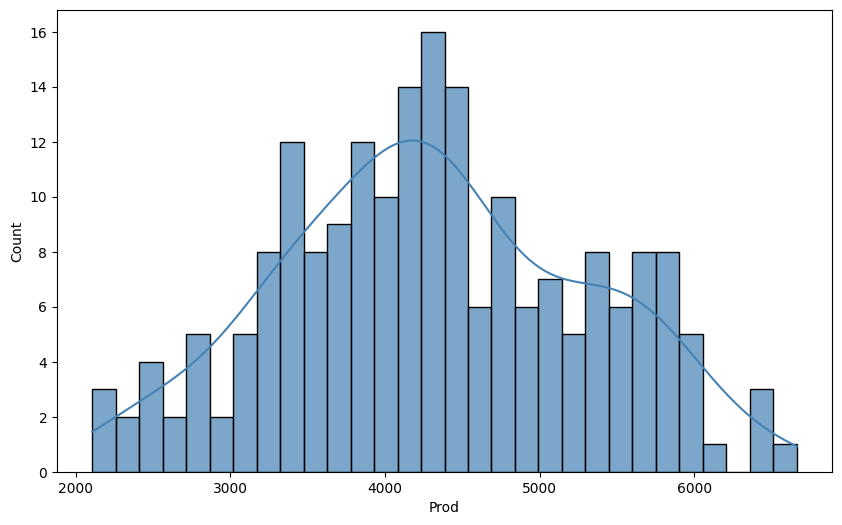

In [200]:
fig, ax = plt.subplots(figsize=(10, 6))

# Гистограмма
sns.histplot(data[target], bins=30, kde=True, color='steelblue', 
             edgecolor='black', alpha=0.7, ax=ax)

**Выводы:**
- В данных отсутсвуют дубликаты и пропуски;
- Распределение признаков близко к нормальному, кроме переменной "Well";
- Со всеми признаками у целевой переменной прямая зависимость, кроме переменной AI.

### Задание 5.1. (2 балла)

Постройте корреляционную матрицу факторов, включив в неё целевой признак. 

Для наглядности визуализируйте полученную матрицу с помощью тепловой карты. 

**Примечание.** *Для визуализации вы можете использовать любую из знакомых вам библиотек.*

На основе построенной корреляционной матрицы ответьте на следующий вопрос:

* Какие факторы сильнее всего коррелируют с целевой переменной?

Вычислите ранг и определитель полученной матрицы корреляций и приведите развёрнутые ответы на следующие вопросы:
* Является ли корреляционная матрица плохо обусловенной (близок ли её опредитель к нулю)?
* Что вы можете сказать о наличии коллинераности/мультиколлинеарности в данных? 
* Применима ли в данном случае модель классической линейной регрессии по методу наименьших квадратов и почему? 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для расчёта корреляционной матрицы;
    * приведён код для визуализации корреляционной матрицы в виде тепловой карты;
    * рассчитаны ранг и определитель корреляционной матрицы;
    * предоставлены обоснованные ответы на все поставленные вопросы. 

- Задание выполнено верно, но не учтено одно условие (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [201]:
# Расчет корреляционной матрицы
corr_matrix = data[all_columns].corr()

corr_matrix

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
Well,1.000000,0.068927,0.077928,0.041483,-0.079252,0.022624,-0.007279,0.026817
Por,0.068927,1.000000,0.760546,-0.461549,-0.218570,0.711831,0.111860,0.861910
Perm,0.077928,0.760546,1.000000,-0.239636,-0.124017,0.471746,0.051023,0.727426
AI,0.041483,-0.461549,-0.239636,1.000000,0.127599,-0.531864,0.499143,-0.390835
Brittle,-0.079252,-0.218570,-0.124017,0.127599,1.000000,-0.214282,0.317929,0.237155
TOC,0.022624,0.711831,0.471746,-0.531864,-0.214282,1.000000,0.299483,0.654445
VR,-0.007279,0.111860,0.051023,0.499143,0.317929,0.299483,1.000000,0.323182
Prod,0.026817,0.861910,0.727426,-0.390835,0.237155,0.654445,0.323182,1.000000


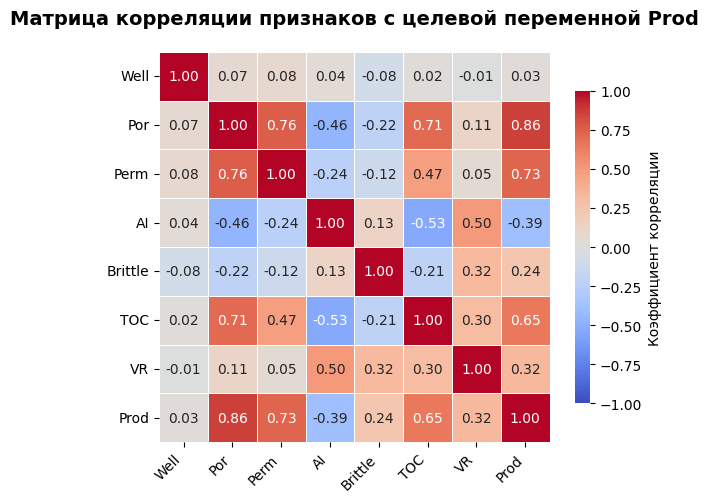

In [202]:
# Построение тепловой карты
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, 
            annot=True,           # показывать значения
            cmap='coolwarm',      # цветовая схема (красный-нейтральный-синий)
            center=0,             # центр шкалы (0)
            fmt='.2f',            # формат чисел (2 знака после запятой)
            square=True,          # квадратные ячейки
            linewidths=0.5,       # линии между ячейками
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'},
            vmin=-1, vmax=1,      # диапазон значений
            annot_kws={'size': 10})  # размер шрифта аннотаций

plt.title('Матрица корреляции признаков с целевой переменной Prod', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [203]:
# топ-3 коррелирующих факторов
corr_matrix['Prod'].apply(lambda x: abs(x)).sort_values(ascending=False)[1:4]

Por     0.861910
Perm    0.727426
TOC     0.654445
Name: Prod, dtype: float64

In [204]:
print(f'Ранг матрицы корреляций: {np.linalg.matrix_rank(corr_matrix)}')

Ранг матрицы корреляций: 8


In [205]:
print(f'Определитель матрицы корреляций: {np.linalg.det(corr_matrix).__round__(5)}')

Определитель матрицы корреляций: 0.00073


**Выводы:**
- Определитель близок к нулю (0.00073), текущая матрица близка к вырожденной. Данные плохо обусловлены, присутствует мультиколлинеарность.
- Коэффициент корреляции между целевой переменной Prod и признаками Por, Perm и TOC составляет 0.86, 0.73 и 0.65, соответственно, что даёт понимание о наличии корреляции средней и сильной связи.
- Модель классической линейной регрессии по методу наименьших квадратов применима, данные отнормированы, но мультиколлинеарность усложняет интерпретацию параметров линейной регрессии.

### Задание 5.2. (2 балла)

Создайте матрицу наблюдений `X` и вектор правильных ответов `y`. В качестве факторов для матрицы наблюдений возьмите все имеющиеся в данных признаки. 

Постройте модель линейной регрессии по методу наименьших квадратов. Для этого воспользуйтесь матричной формулой МНК и инструментарием библиотеки numpy. 

Выведите на экран полученные оценки коэффициентов модели, округлённые до целого.

Приведите подробные выводы по полученным результатам, ответив на следующие вопросы:
* Есть ли в ваших данных признаки, которые, согласно модели, можно назвать неинформативными, то есть они не оказывают влияния на целевую переменную или оказывают шумовое влияние?
* Приведите интерпретацию нескольких (двух или трёх) коэффициентов полученной модели линейной регрессии.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для нахождения параметров модели линейной регрессии с помощью матричной формулы МНК;
    * на основе полученных параметров даны верные ответы на поставленные вопросы;
    * приведена корректная интерпретация нескольких коэффициентов полученной модели линейной регрессии.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [206]:
# Создаем матрицу X и вектор y
X = np.column_stack((
        np.ones(data.shape[0]), 
        data.iloc[:, :-1].values
        )
    )
y = data['Prod'].values

# вычисляем OLS-оценку для коэффициентов без стандартизации
w_hat = np.linalg.inv(X.T@X) @ X.T@y

# составляем датафрейм из признаков и округленных коэффициентов
w_hat_df = pd.DataFrame(
    data=np.round(w_hat, 0), 
    index=np.hstack((
        ['Intercept'], 
        np.array(data.columns[:-1])
        )
    ),
    columns = ['Coefficients']
)

In [207]:
# Выводим результат
print("=== Коэффициенты линейной регрессии ===\n")
print(w_hat_df)

# Дополнительно: проверим размерности
print(f"\nРазмерность X: {X.shape}")
print(f"Размерность y: {y.shape}")
print(f"Размерность w_hat: {w_hat.shape}")

=== Коэффициенты линейной регрессии ===

           Coefficients
Intercept       -1232.0
Well                0.0
Por               230.0
Perm              116.0
AI               -365.0
Brittle            25.0
TOC               -78.0
VR                785.0

Размерность X: (200, 8)
Размерность y: (200,)
Размерность w_hat: (8,)


**Выводы:**
- Признак Well является неинформативным, так как его коэффициент равен 0.0. Он не влияет на вычисления, в сравнении с другими признаками.
- Самыми влиятельными признаками яляются Por с положительным коэффициентом (прямое влияние), AI с отрицательным (влияние в сторону уменьшения).
- Среди коэффициентов есть значения как с положительным, так и с отрицательным влиянием на целевую переменную. Так, например, коэффициенты AI и TOC оказывают обратное влияние назначение переменной Prod, в случае увеличения значения таких значений - мы получим прогноз уменьшения выработки в скважине.

### Задание 5.3. (1 балл)

Теперь потренируемся строить предсказание для наблюдений целевой переменной. 

**а)** Постройте прогноз выработки газа для скважины со следующими параметрами:

```python
{
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
 }
```

Рассчитайте абсолютную ошибку построенного вами прогноза для предложенной скважины (в миллионах кубических футов в день), если известно, что на этой скважине производится `4748.315024` миллионов кубических футов газа в день. 

**б)** Постройте прогноз выработки газа для всех скважин из обучающего набора данных. Выберите метрику, по которой вы будете оценивать качество регрессионных моделей и сравнивать их между собой (можно использовать несколько метрик, но не более двух).

Рассчитайте значение выбранной метрики для вашей модели. Приведите интерпретацию полученного результата. 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для построения прогноза выработки газа на указанной скважине и рассчитана абсолютная ошибка прогноза для этой скважины;
    * выбрана корректная для поставленной задачи метрика (или метрики) оценки качества модели и приведён код для расчёта этой метрики на всём обучающем наборе данных;
    * приведена корректная интерпретация полученного результата.

- Задание выполнено верно, но не учтено одно из условий, или задание выполнено неверно (**0 баллов**).

In [208]:
# прогнозируемые значения
x_new = np.array([1, 106, 15.32, 3.71, 3.29, 55.99, 1.35, 2.42])
y_new = 4748.315024

# прогнозное значение выработки
y_new_pred_new = np.round(x_new@w_hat, 5)
print(f'Прогноз выработки газа, фут^3/день: {y_new_pred_new}')
print (f'Абсолютная ошибка выработки газа, фут^3/день: {np.round(np.abs(y_new - y_new_pred_new), 5)}')

Прогноз выработки газа, фут^3/день: 4723.06405
Абсолютная ошибка выработки газа, фут^3/день: 25.25097


In [209]:
# вычисляем метрику модели
y_pred = X@w_hat
print(f'MAPE модели: {(metrics.mean_absolute_percentage_error(y, y_pred)*100):.2f} %')

MAPE модели: 3.63 %


**Выводы:**

Для данной модели, построенной на всех признаках, в том числе и мультиколлинеарных, показатель MAPE в 3.6 % можно считать довольно низким. Модель в данном случае отработала хорошо. Но, учитывая, что данные, на которых построена модель, плохо обусловлены, то при других значениях модель может показать как хороший результат, так и плохой.

### Задание 5.4. (1 балл)

Настало время анализа построенной модели. Посмотрите на коэффициенты и сравните их знаки со значениями выборочных корреляций между целевым признаком и факторами, которые вы нашли ранее.

Дайте развёрнутые ответы на следующие вопросы:

* Есть ли в вашей модели фактор, при котором коэффициент в модели линейной регрессии противоречит соответствующему коэффициенту корреляции? Например, корреляция говорит, что зависимость между фактором и целевой переменной прямая, а модель говорит обратное. Если таких факторов несколько, укажите их все.
* Как вы считаете, с чем связано полученное противоречие результатов?

**Критерии оценивания:**

- Задание выполнено верно, даны корректные развёрнутые ответы на все поставленные в задании вопросы (**1 балл**). 

- Задание выполнено неверно, даны некорректные ответы на один или несколько поставленных в задании вопросов (**0 баллов**).

,Coefficients
Well,0.0
Por,230.0
Perm,116.0
AI,-365.0
Brittle,25.0
TOC,-78.0
VR,785.0


Well       0.026817
Por        0.861910
Perm       0.727426
AI        -0.390835
Brittle    0.237155
TOC        0.654445
VR         0.323182
Name: Prod, dtype: float64

[Text(0.5, 0, "Признак 'TOC'"),
 Text(0, 0.5, "Целевой признак 'Prod'"),
 Text(0.5, 1.0, 'Диаграмма рассеяния TOC/Prod')]

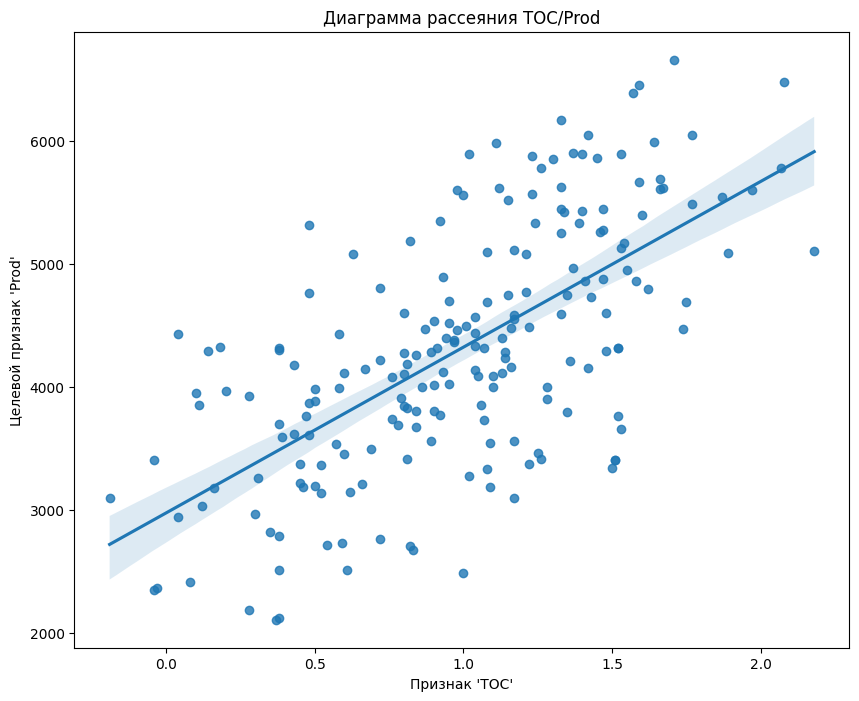

In [210]:
# вывод вектора МНК и матрицы корреляций для сравнения значений
display(w_hat_df[1:])
display(corr_matrix['Prod'][:-1])

# полотно для построения графика
plt.subplots(figsize=(10, 8))

# диаграмма рассеяния + линейная регрессия
ax_regplot = sns.regplot(data=data, x='TOC', y='Prod')
ax_regplot.set(
    xlabel="Признак 'TOC'", 
    ylabel="Целевой признак 'Prod'", 
    title='Диаграмма рассеяния TOC/Prod'
)

**Выводы:**
- По графику видно, что между признаком TOC и целевой переменной Prod прямая и линейная зависимость, с ростом одного признака, растет и другой.
- Для признака TOC имеется расхождение между знаками значений, полученных по МНК и в корреляционной матрице. Так как коэффициент корреляции положительный, можно сделать вывод что векторы TOC и Prod сонаправлены.
- Коэффициент со знаком минус, полученный для TOC по МНК, говорит о том, что значение целевой переменной будет падать, при увеличении данного признака, что не совпадает с предыдущим выводом. Так, ошибка модели будет больше с каждым разом. Такое расхожедние может быть обусловлено сильной мультиколлинеарностью в данных (связь более 0.7).

### Задание 5.5. (2 балла)

* Исключите из данных сильно коррелированные между собой факторы. Под сильной корреляцией в данной задаче будем понимать значения выше `0.7`.

Выбирая, какой из коррелированных факторов оставить, руководствуйтесь коэффициентом корреляции с целевой переменной: оставляйте тот фактор, который больше всего коррелирует с целевой переменной (объёмом добычи газа).

* Также исключите из данных факторы, для которых корреляция с целевой переменной меньше `0.05`.

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого используйте матричную формулу и библиотеку numpy. Выведите значение полученных коэффициентов, округлённых до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте выбранную вами ранее метрику (или метрики). 

Дайте подробные ответы на следующие вопросы:

* Приведите интерпретацию нескольких полученных коэффициентов (двух или трёх). Сравните их значения с полученными ранее.
* Приведите интерпретацию полученных значений метрик. Сравните их значения с полученными ранее. 
* Удалось ли вам побороть противоречие коэффициентов линейной регрессии и коэффициентов корреляции?

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * отобраны верные факторы;
    * на основе отобранных факторов построена модель линейной регрессии с помощью матричной формулы МНК и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * даны ответы на все поставленные в задании вопросы.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено верно, не учтено несколько из условий (**0 баллов**).

In [211]:
# обновляем исходный датасет
drop_columns = ['Perm', 'TOC', 'Well']
data.drop(columns=drop_columns, axis=1, inplace=True)

target = 'Prod'
features = [col for col in data.columns if col != target]
all_columns = features + [target]

In [212]:
# Создаем матрицу X и вектор y
X = np.column_stack((
        np.ones(data.shape[0]), 
        data.iloc[:, :-1].values
        )
    )
y = data['Prod'].values

# вычисляем OLS-оценку для коэффициентов без стандартизации
w_hat_new = np.linalg.inv(X.T@X) @ X.T@y

# составляем датафрейм из признаков и округленных коэффициентов
w_hat_df_new = pd.DataFrame(
    data=np.round(w_hat_new, 0), 
    index=np.hstack((
        ['Intercept'], 
        np.array(data.columns[:-1])
        )
    ),
    columns = ['Coefficients']
)

In [213]:
# Выводим результат
print("=== Коэффициенты линейной регрессии ===\n")
print(w_hat_df_new)

# Дополнительно: проверим размерности
print(f"\nРазмерность X: {X.shape}")
print(f"Размерность y: {y.shape}")
print(f"Размерность w_hat: {w_hat_new.shape}")

=== Коэффициенты линейной регрессии ===

           Coefficients
Intercept       -1835.0
Por               293.0
AI               -200.0
Brittle            28.0
VR                517.0

Размерность X: (200, 5)
Размерность y: (200,)
Размерность w_hat: (5,)


In [214]:
X_new = np.column_stack((np.ones(data.shape[0]), data[features].values))

# предсказание на всем датасете с новыми коэффициентами
y_pred_new = X_new@w_hat_new
print(f'MAPE модели: {(metrics.mean_absolute_percentage_error(y, y_pred_new)*100):.2f} %')

# сравниваем коэффициенты вектора линейной регрессии и матрицы корреляций
display(w_hat_df_new[1:])
display(data.corr()['Prod'][:-1])

MAPE модели: 4.04 %


,Coefficients
Por,293.0
AI,-200.0
Brittle,28.0
VR,517.0


Por        0.861910
AI        -0.390835
Brittle    0.237155
VR         0.323182
Name: Prod, dtype: float64

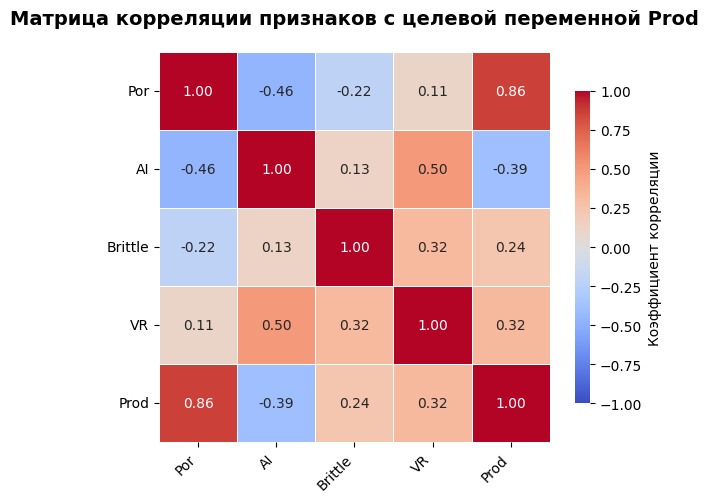

In [215]:
# Расчет корреляционной матрицы
corr_matrix_new = data[all_columns].corr()

# Построение тепловой карты
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix_new , 
            annot=True,           # показывать значения
            cmap='coolwarm',      # цветовая схема (красный-нейтральный-синий)
            center=0,             # центр шкалы (0)
            fmt='.2f',            # формат чисел (2 знака после запятой)
            square=True,          # квадратные ячейки
            linewidths=0.5,       # линии между ячейками
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'},
            vmin=-1, vmax=1,      # диапазон значений
            annot_kws={'size': 10})  # размер шрифта аннотаций

plt.title('Матрица корреляции признаков с целевой переменной Prod', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [216]:
print(f'Определитель матрицы корреляций: {np.linalg.det(np.corrcoef(X_new[:, 1:].T)).__round__(5)}')

Определитель матрицы корреляций: 0.36826


**Выводы:**
- Были удалены признаки, наиболее сильно скоррелированые между собой (Por - Perm и Por - TOC), а также признак Well с минимальной корреляцией с целевой переменной. Это помогло модели синхронизироаться по вектору коэффициентов МНК с матрицей корреляций.
- Метрика MAPE модели незначительно ухудшилась (с 3.63% до 4.04%), но тем не менее остается достаточно низкой.
- Определитель матрицы с меньшим количеством признаков увеличился до 0.368, что говорит об улучшении модели в направлении более стабильных прогнозируемых результатов.
- Коэффициенты вектора линейной регрессии, по сравнению с моделью, обученной на всех признаках немного изменились в значениях, знаки остались неименны. Por, Brittle, VR оказывают положительное влияние на целевую переменную, AI - обратная зависимость.

### Задание 5.6. (1 балл)

Наконец, давайте построим модель линейной регрессии из библиотеки `scikit-learn (sklearn)` и сравним результаты её работы с теми, что нам удалось получить вручную. 

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого воспользуйтесь классом `LinearRegression` из библиотеки `sklearn`. Выведите значения полученных коэффициентов, округлённые до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте значение выбранной вами метрики (или метрик).

Сравните результаты библиотечной реализации с тем, что вы получили ранее. 

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов построена модель линейной регрессии из библиотеки sklearn и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * приведён вывод о соответствии результатов, полученных вручную и с помощью библиотеки.
- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [217]:
# создаём модель линейной регрессии
LR = linear_model.LinearRegression(fit_intercept=False)

# обучаем модель
LR.fit(X_new, y)

# собираем коэффициенты линейной регрессии в датафрейм
w_hat_df_lr = pd.DataFrame(
    data=np.round(LR.coef_, 0), 
    index=np.hstack((
            ['Intercept'], 
            np.array(data.columns[:-1])
            )
        ),
        columns = ['Coefficients']
    )

# смотрим результат
display(w_hat_df_lr)

# делаем предсказание
y_new_pred_new_lr = LR.predict(X_new)

print(f'MAPE модели: {(metrics.mean_absolute_percentage_error(y, y_new_pred_new_lr)*100):.2f} %')

,Coefficients
Intercept,-1835.0
Por,293.0
AI,-200.0
Brittle,28.0
VR,517.0


MAPE модели: 4.04 %


**Выводы:**

Коэффициенты, полученные в результате обучения модели LinearRegression из библиотеки scikit-learn, идентичны значениям коэффициентов, полученных путём применения матричной формулы с помощью NumPy. Это подтверждает, что алгоритм scikit-learn построен на тех же правилах, что и аналитический метод наименьших квадратов.

## Практика: полиномиальная регрессия и регуляризация

Мы продолжаем работать над задачей от владельца компании «Газ-Таз-Ваз-Нефть» Василия.

Ранее мы построили модель линейной регрессии, которая прогнозирует выработку газа на скважине. Для этого мы с помощью матрицы корреляций и рассуждений отобрали некоррелированные, значимые для предсказания признаки. **Далее мы будем использовать именно их (см. задание 5.5).**

Мы хотим улучшить результат — уменьшить ошибку прогноза. Для этого мы воспользуемся моделью полиномиальной регрессии третьей степени. Однако теперь мы знаем, что полиномиальным моделям очень легко переобучиться под исходную выборку. Так как данных у нас не так много (всего 200 скважин), то для контроля качества модели мы будем использовать кросс-валидацию. 

Приступим! Выполните задания 8.1–8.5:


In [218]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

### Задание 8.1. (1 балл)

Стандаризируйте признаки с помощью `StandartScaler` из библиотеки `sklearn`. 

Затем сгенерируйте полиномиальные признаки третьего порядка на факторах, которые вы выбрали для обучения моделей. Для этого воспользуйтесь генератором полиномов `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` установите в значение `False`.

Выведите на экран, сколько факторов у вас получилось после генерации полиномиальных признаков.

**Важно:** стандартизацию необходимо произвести до генерации полиномиальных факторов!

Обучите модель линейной регрессии из библиотеки `sklearn` (`LinearRegression`) на полученных полиномиальных факторах.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов сгенерированы полиномиальные признаки третьего порядка;
    * построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).
- Задание выполнено неверно, не учтено одно или несколько из условий (**0 баллов**).

In [219]:
# инициализируем стандартизатор StandardScaler
SS_scaler = StandardScaler()

# подгоняем параметры стандартизатора на данных без единичного столбца
X_scaled = SS_scaler.fit_transform(X_new[:, 1:])

# добавляем полиномиальные признаки
PF = PolynomialFeatures(degree=3, include_bias=False)
X_poly = PF.fit_transform(X_scaled)

print(f'Количество полиномиальных признаков: {X_poly.shape[1]}')

Количество полиномиальных признаков: 34


In [220]:
# Расчитаем метрики для модели LR через кросс-валидацию
cv_results = cross_validate(
    LR, 
    X_new, y, 
    scoring='neg_mean_absolute_percentage_error', 
    cv=5, 
    return_train_score=True
)

# Расчет MAPE в процентах
train_mape = -cv_results['train_score'].mean() * 100
test_mape = -cv_results['test_score'].mean() * 100

print("MAPE МОДЕЛИ LR (через кросс-валидацию)")
print()
print(f'MAPE на тренировочных фолдах: {train_mape:.2f} %')
print(f'MAPE на валидационных фолдах: {test_mape:.2f} %')
print(f"Разница (train - test): {(-train_mape) - (-test_mape):.2f}%")

MAPE МОДЕЛИ LR (через кросс-валидацию)

MAPE на тренировочных фолдах: 4.02 %
MAPE на валидационных фолдах: 4.23 %
Разница (train - test): 0.21%


In [221]:
# Обучение модели линейной регрессии на полиномиальных признаках
model = linear_model.LinearRegression()

# Кросс-валидация
cv_results = cross_validate(
    model, 
    X_poly, y, 
    scoring='neg_mean_absolute_percentage_error', 
    cv=5, 
    return_train_score=True
)

# MAPE
cv_train = cv_results['train_score'].mean() * 100  # умножаем на 100 для процентов
cv_test = cv_results['test_score'].mean() * 100

# Вывод метрик
print("РЕЗУЛЬТАТЫ МОДЕЛИ (ПОЛИНОМИАЛЬНЫЕ ПРИЗНАКИ, deg=3)")
print()
print(f'MAPE на тренировочных фолдах: {-cv_train:.2f} %')
print(f'MAPE на валидационных фолдах: {-cv_test:.2f} %')
print(f"Разница (train - test): {(-cv_train) - (-cv_test):.2f}%")


РЕЗУЛЬТАТЫ МОДЕЛИ (ПОЛИНОМИАЛЬНЫЕ ПРИЗНАКИ, deg=3)

MAPE на тренировочных фолдах: 1.77 %
MAPE на валидационных фолдах: 2.68 %
Разница (train - test): -0.91%


**Выводы:**
- Полиномиальная регрессия, в отличие от линейной, является не прямой, а кривой через все наблюдения. Благодаря использованию полинома получается построить более точную модель с меньшим отклонением от среднего.
- В результате применения полиномиальной регрессии и кросс-валидации по 5-ти фолдам улучшились в 2 раза показатели метрики MAPE на тренировочной выборке и на 60 % на валидационной выборке.
- Переход к стандартизованным полиномиальным коэффициентам значительно улучшил модель и сократил перетренированность модели.

### Задание 8.2. (2 балла)

Теперь попробуем воспользоваться линейной регрессией с регуляризацией. Для начала возьмём $L_1$-регуляризацию.

Обучите модель `Lasso` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Lasso), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [222]:
# Определение сетки гиперпараметров для поиска
param_grid = {
    'alpha': np.logspace(-4, 1, 30)  # от 0.0001 до 10 (30 значений)
}

# Создание модели Lasso
lasso = linear_model.Lasso(random_state=42, max_iter=10000)

# Подбор гиперпараметров через GridSearch
lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',  # оптимизируем MAPE
    cv=5,  # 5-кратная кросс-валидация
    n_jobs=-1,  # используем все ядра процессора
    verbose=1  # показываем прогресс
)

# Обучаем GridSearchCV на полиномиальных признаках
lasso_grid.fit(X_poly, y)

# Лучший найденный alpha
best_alpha = lasso_grid.best_params_['alpha']
best_score = -lasso_grid.best_score_ * 100  # переводим в проценты

print()
print(f"Лучший alpha: {best_alpha:.6f}")
print(f"Лучший MAPE (CV): {best_score:.2f}%")

# Оценка модели с лушими параметрами на кросс-валидации
best_lasso = lasso_grid.best_estimator_

cv_results_lasso = cross_validate(
    best_lasso, 
    X_poly, y, 
    scoring='neg_mean_absolute_percentage_error', 
    cv=5, 
    return_train_score=True
)

# Расчет MAPE
lasso_train = cv_results_lasso['train_score'].mean() * 100
lasso_test = cv_results_lasso['test_score'].mean() * 100
lasso_train_std = cv_results_lasso['train_score'].std() * 100
lasso_test_std = cv_results_lasso['test_score'].std() * 100

# 5. ВЫВОД РЕЗУЛЬТАТОВ LASSO
print()
print("РЕЗУЛЬТАТЫ МОДЕЛИ LASSO (L1-РЕГУЛЯРИЗАЦИЯ)")
print()
print(f"Гиперпараметры:")
print(f"  - alpha: {best_alpha:.6f}")
print(f"\nМетрики на кросс-валидации (5 фолдов):")
print(f"  - MAPE на тренировочных фолдах: {-lasso_train:.2f}%")
print(f"  - MAPE на валидационных фолдах: {-lasso_test:.2f}%")
print(f"  - Разница (train - test): {(-lasso_train) - (-lasso_test):.2f}%")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Лучший alpha: 4.520354
Лучший MAPE (CV): 2.28%

РЕЗУЛЬТАТЫ МОДЕЛИ LASSO (L1-РЕГУЛЯРИЗАЦИЯ)

Гиперпараметры:
  - alpha: 4.520354

Метрики на кросс-валидации (5 фолдов):
  - MAPE на тренировочных фолдах: 1.82%
  - MAPE на валидационных фолдах: 2.28%
  - Разница (train - test): -0.46%


**Выводы:**
- Обучение модели проводилось на стандартизированных данных с последующей генерацией полиномиальных признаков 3-й степени.
- Использование модели Lasso улучшило валидационную ошибку с 2.68% до 2.28% (улучшение на 15%). Ошибка на тренировочной выборке почти не изменилась (1.77% → 1.82%). 
- Переобучение уменьшилось: разница между MAPE на тренировочных и валидационных фолдах сократилась с 0.91% до 0.46% (снижение на 49%).
- Для подбора гиперпараметров применен GridSearchCV с 5-кратной кросс-валидацией.
- Подобранный коэффициент регуляризации alpha = 4.52 указывает на необходимость существенной регуляризации из-за большого количества полиномиальных признаков.

### Задание 8.3. (2 балла)

Проделаем то же самое с $L_2$-регуляризацией.

Обучите модель `Ridge` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Ridge), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [223]:
# Определение сетки гиперпараметров для поиска
param_grid = {
    'alpha': np.logspace(-4, 2, 50)  # от 0.0001 до 100 (50 значений)
}

# Создание модели Ridge
ridge = linear_model.Ridge(random_state=42, max_iter=10000)

# Подбор гиперпараметров через GridSearchCV
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',  # оптимизируем MAPE
    cv=5,  # 5-кратная кросс-валидация
    n_jobs=-1,  # используем все ядра процессора
    verbose=1  # показываем прогресс
)

# Обучаем GridSearchCV на полиномиальных признаках
ridge_grid.fit(X_poly, y)

# Лучший найденный alpha
best_alpha_ridge = ridge_grid.best_params_['alpha']
best_score_ridge = -ridge_grid.best_score_ * 100  # переводим в проценты

print()
print(f"Лучший alpha (Ridge): {best_alpha_ridge:.6f}")
print(f"Лучший MAPE (CV): {best_score_ridge:.2f}%")

# Оценка модели с лушими параметрами на кросс-валидации
best_ridge = ridge_grid.best_estimator_

cv_results_ridge = cross_validate(
    best_ridge, 
    X_poly, y, 
    scoring='neg_mean_absolute_percentage_error', 
    cv=5, 
    return_train_score=True
)

# Расчет MAPE
ridge_train = cv_results_ridge['train_score'].mean() * 100
ridge_test = cv_results_ridge['test_score'].mean() * 100
ridge_train_std = cv_results_ridge['train_score'].std() * 100
ridge_test_std = cv_results_ridge['test_score'].std() * 100

# Вывод результатов Ridge
print()
print("РЕЗУЛЬТАТЫ МОДЕЛИ RIDGE (L2-РЕГУЛЯРИЗАЦИЯ)")
print()
print(f"Гиперпараметры:")
print(f"  - alpha: {best_alpha_ridge:.6f}")
print(f"\nМетрики на кросс-валидации (5 фолдов):")
print(f"  - MAPE на тренировочных фолдах: {-ridge_train:.2f}%")
print(f"  - MAPE на валидационных фолдах: {-ridge_test:.2f}%")
print(f"  - Разница (train - test): {(-ridge_train) - (-ridge_test):.2f}%")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Лучший alpha (Ridge): 0.152642
Лучший MAPE (CV): 2.67%

РЕЗУЛЬТАТЫ МОДЕЛИ RIDGE (L2-РЕГУЛЯРИЗАЦИЯ)

Гиперпараметры:
  - alpha: 0.152642

Метрики на кросс-валидации (5 фолдов):
  - MAPE на тренировочных фолдах: 1.77%
  - MAPE на валидационных фолдах: 2.67%
  - Разница (train - test): -0.90%


**Выводы:**
- Ridge не показал улучшения ни по одному из показателей. Результат модели практически идентичен обычной полиномиальной регрессии.
- Из-за невозможности обнулять признаки L2-регуляризация не справляется с переобучением, вызванным большим количеством полиномиальных признаков 3-й степени.
- Alpha успешно подобран через GridSearchCV. Но оптимальный alpha оказался близким к нулю, это очень слабая регуляризация. При alpha → 0 Ridge превращается в Linear Regression.

### Задание 8.4. (2 балла)

Наконец, настало время комбинировать $L_1$ и $L_2$ -регуляризации.

Обучите модель `ElasticNet` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициенты регуляризации (`alpha` и `l1-ratio`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение метрики MAPE на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (ElasticNet), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [224]:
# 2. Определение сетки гиперпараметров для ElasticNet
param_grid = {
    'alpha': np.logspace(-3, 1, 30),      # от 0.001 до 10 (общая сила регуляризации)
    'l1_ratio': np.linspace(0, 1, 11)     # от 0 до 1 (пропорция L1/L2)
}

# Создание модели ElasticNet
elasticnet = linear_model.ElasticNet(
    random_state=42, 
    max_iter=10000,
    tol=0.0001
)

# Подбор гиперпараметров через GridSearchCV
elasticnet_grid = GridSearchCV(
    estimator=elasticnet,
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',  # оптимизируем MAPE
    cv=5,  # 5-кратная кросс-валидация
    n_jobs=-1,  # используем все ядра
    verbose=1  # показываем прогресс
)

# Обучаем GridSearchCV
elasticnet_grid.fit(X_poly, y)

# Лучшие гиперпараметры
best_alpha = elasticnet_grid.best_params_['alpha']
best_l1_ratio = elasticnet_grid.best_params_['l1_ratio']
best_score = -elasticnet_grid.best_score_ * 100

print()
print("РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ")
print(f"Лучший alpha: {best_alpha:.6f}")
print(f"Лучший l1_ratio: {best_l1_ratio:.3f}")
print(f"Лучший MAPE (CV): {best_score:.2f}%")

# Оценка модели с лушими параметрами на кросс-валидации
best_elasticnet = elasticnet_grid.best_estimator_

cv_results_en = cross_validate(
    best_elasticnet, 
    X_poly, y, 
    scoring='neg_mean_absolute_percentage_error', 
    cv=5, 
    return_train_score=True
)

# Расчет MAPE
en_train = cv_results_en['train_score'].mean() * 100
en_test = cv_results_en['test_score'].mean() * 100
en_train_std = cv_results_en['train_score'].std() * 100
en_test_std = cv_results_en['test_score'].std() * 100

# Вывод результатов
print()
print("РЕЗУЛЬТАТЫ МОДЕЛИ ELASTICNET (L1 + L2 РЕГУЛЯРИЗАЦИЯ)")
print()
print(f"Гиперпараметры:")
print(f"  - alpha (общая регуляризация): {best_alpha:.6f}")
print(f"  - l1_ratio (доля L1): {best_l1_ratio:.3f}")
print()
print(f"\nМетрики на кросс-валидации (5 фолдов):")
print(f"  - MAPE на тренировочных фолдах: {-en_train:.2f}% (+/- {en_train_std:.2f}%)")
print(f"  - MAPE на валидационных фолдах: {-en_test:.2f}% (+/- {en_test_std:.2f}%)")
print(f"  - Разница (train - test): {(-en_train) - (-en_test):.2f}%")

Fitting 5 folds for each of 330 candidates, totalling 1650 fits

РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ
Лучший alpha: 5.298317
Лучший l1_ratio: 1.000
Лучший MAPE (CV): 2.28%

РЕЗУЛЬТАТЫ МОДЕЛИ ELASTICNET (L1 + L2 РЕГУЛЯРИЗАЦИЯ)

Гиперпараметры:
  - alpha (общая регуляризация): 5.298317
  - l1_ratio (доля L1): 1.000


Метрики на кросс-валидации (5 фолдов):
  - MAPE на тренировочных фолдах: 1.83% (+/- 0.03%)
  - MAPE на валидационных фолдах: 2.28% (+/- 0.29%)
  - Разница (train - test): -0.44%


**Выводы:**
- В качестве оптимальных гиперпараметров подобраны значения: alpha = 5, l1_ratio = 1. l1_ratio = 1 означает выбор чистой L1-регуляризации.
- ElasticNet выбрал чистое Lasso, полностью отказавшись от L2-компоненты. Это подтверждает, что для данной задачи эффективна только L1-регуляризация, а L2-компонента не дает преимуществ.
- ElasticNet и Lasso показали идентичные результаты. ElasticNet не добавил преимуществ, но и не ухудшил качество (MAPE test = 2.28%).
- Минимальное переобучение: Разница train-test = 0.44% (лучший показатель среди всех моделей).

### Задание 8.5. (1 балл)

Завершением вашей работы будет сводная таблица результатов, которую вы представите на презентации заказчику Василию.

Составьте таблицу (DataFrame) со следующими столбцами (имена столбцов выберите самостоятельно):
* Наименование модели.
* Гиперпараметры (коэффициенты регуляризации, если таковые имеются), если нет — оставьте ячейку пустой.
* Использовались ли полиномиальные признаки при построении модели (Да/Нет или True/False).
* Значение выбранной метрики на тренировочных фолдах при кросс-валидации модели.
* Значение выбранной метрики на валидационных фолдах при кросс-валидации модели.

Сделайте финальный вывод по проделанной работе. Какая линейная модель из тех, что мы рассмотрели, показала наилучший результат с точки зрения качества на валидационных фолдах, а также с точки зрения переобученности?

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * верно составлена сводная таблица итоговых результатов построенных ранее моделей с указанными в задании столбцами;
    * приведены итоговые выводы по проделанной работе, указано, какая из рассмотренных моделей показала наилучший результат.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [225]:
import pandas as pd

# Данные о моделях в заданном порядке
models_info = [
    ('Linear Regression', None, False, train_mape, test_mape),
    ('Polynomial Regression', None, True, cv_train, cv_test),
    ('Lasso (L1)', lasso_grid, True, lasso_train, lasso_test),
    ('Ridge (L2)', ridge_grid, True, ridge_train, ridge_test),
    ('ElasticNet (L1+L2)', elasticnet_grid, True, en_train, en_test)
]

results = []

for name, grid, has_poly, train_mape, test_mape in models_info:
    # Убираем минусы из MAPE
    train_mape = abs(train_mape) if train_mape is not None else None
    test_mape = abs(test_mape) if test_mape is not None else None
    
    if grid is not None:
        best_model = grid.best_estimator_
        if hasattr(best_model, 'alpha') and hasattr(best_model, 'l1_ratio'):
            params = f'alpha = {best_model.alpha:.6f}, l1_ratio = {best_model.l1_ratio:.3f}'
        elif hasattr(best_model, 'alpha'):
            params = f'alpha = {best_model.alpha:.6f}'
        else:
            params = 'Без подбора гиперпараметров'
    else:
        params = 'Без подбора гиперпараметров'
    
    # Рассчитываем разницу
    if train_mape is not None and test_mape is not None:
        diff = test_mape - train_mape
        diff_rounded = round(diff, 2)
    else:
        diff_rounded = None
    
    results.append({
        'Модель': name,
        'Гиперпараметры': params,
        'Полиномиальные признаки': 'Да' if has_poly else 'Нет',
        'MAPE train (%)': round(train_mape, 2) if train_mape is not None else None,
        'MAPE test (%)': round(test_mape, 2) if test_mape is not None else None,
        'Разница (test - train) (%)': diff_rounded
    })

# Создаем DataFrame (без сортировки, порядок сохраняется)
results_df = pd.DataFrame(results)

# Выводим DataFrame
results_df

,Модель,Гиперпараметры,Полиномиальные признаки,MAPE train (%),MAPE test (%),Разница (test - train) (%)
0,Linear Regression,Без подбора гиперпараметров,Нет,4.02,4.23,0.21
1,Polynomial Regression,Без подбора гиперпараметров,Да,1.77,2.68,0.91
2,Lasso (L1),"alpha = 4.520354, l1_ratio = 1.000",Да,1.82,2.28,0.46
3,Ridge (L2),alpha = 0.152642,Да,1.77,2.67,0.90
4,ElasticNet (L1+L2),"alpha = 5.298317, l1_ratio = 1.000",Да,1.83,2.28,0.44


**Выводы:**
- Самые слабые показатели у модели простой линейной регрессии LinearRegression без преобразования признаков (MAPE test = 4.23%).
- Модель линейной регрессии с добавлением полиномиальных признаков показывает значительное улучшение по сравнению с линейной моделью (MAPE test = 2.68%). Но наблюдается наибольшее переобучение среди всех моделей (Разница train-test = 0.91%).
- Модель с L2-регуляризацией - Ridge, показывает практически идентичные полиномиальной регрессии результаты MAPE test = 2.67% и сохраняется высокий уровень переобучения (Разница train-test = 0.90%). L2-регуляризация неэффективна, так как не может обнулять шумовые признаки
- Лучшие результаты показали модели линейной регрессии с добавлением L1-регуляризации - Lasso и линейной регрессии смешанного типа, с "гибридной" регуляризацией - ElasticNet. 
- Результаты двух лучших моделей идентичны, так как процесс оптимизации трансформировал ElasticNet в Lasso: MAPE test = 2.28% (на 15% лучше полиномиальной регрессии), Разница train-test = 0.46% (снижение переобучения на 49%).

# Общий вывод по проекту:

1. Линейная регрессия с полиномиальными признаками показывает гораздо лучшие результаты, они существенно улучшают модель.
2. При правильном выборе типа регуляризации и его параметров можно улучшить предсказание, сократить переобучение модели.
3. В данной задаче лучшие результаты показали модели линейной регрессией с полиномиальными коэффициентами и 
L1-регуляризацией - Lasso или ElasticNet с 
L1-регуляризацией. 